In [1]:
#The first preprocessing steps are the same as in the Multiclass file. (Only added label encoding)
#This file was used to get the accuracies of both the logistic regression and neural net for the multiclass case

In [2]:
#Data read out and defining the variables:
import scipy.io
data = scipy.io.loadmat('210921.mat')

spks = data['spks']
tc = data['tc']
cue = data['cueAng']
cueIdx = data['cueAngIdx']
corr = data['isCorr']

#Here I selected the correct trials only and .flatten was needed since the dimension need to match.
corr = corr.flatten()
cueIdx = cueIdx.flatten()
corr_bool = corr == 1

#Only keeping the correct trials:
spks = spks[corr_bool]
cueIdx = cueIdx[corr_bool]


In [4]:
#Here I encoded the labels since we have 8 different labels.
from sklearn.preprocessing import LabelEncoder
y = cueIdx.astype(int)
encoder = LabelEncoder()
y_labels = encoder.fit_transform(y)


In [5]:
#Here the boxcar smoothing and downsampling are done.
#I have done this in another way for the multiclass case because the kernel kept dying if I first smoothed it fully and then downsampled it. 
#Here it is immediately downsampled after the smoothing and only that is stored.
import numpy as np
n_trials, n_time_raw, n_neurons = spks.shape

window_ms = 100 #For the smoothing 100ms
sample_step = 10 #For downsampling 10ms

#Defining the kernel:
boxcar_kernel = np.ones(window_ms, dtype=float) / window_ms

# Number of time points after downsampling.
n_time_down = len(np.arange(0, n_time_raw, sample_step))

#List to input the smooth data to:
spks_smooth = np.zeros((n_trials, n_time_down, n_neurons), dtype=float)


#Looping over trials and neurons and then convolving over time to get a smooth representation.
for trial in range(n_trials):
    for neuron in range(n_neurons):

        smoothed = np.convolve(spks[trial, :, neuron],boxcar_kernel,mode="same")
        # Sample every 10 ms
        spks_smooth[trial, :, neuron] = smoothed[::sample_step]


In [6]:
#Calculate z-score.
#List to store the scores:
z_score = np.zeros_like(spks_smooth)

#Loop over each timepoint and then computing the z-score formula:
for t in range(spks_smooth.shape[1]):
    mean = spks_smooth[:, t, :].mean(axis=0)
    std = spks_smooth[:, t, :].std(axis=0)
    z_score[:, t, :] = (spks_smooth[:, t, :] - mean) / (std + 1e-10) #1e-10 was needed to avoid division by 0.


dt = 0.01  
time = -0.5 + np.arange(spks_smooth.shape[1]) * dt

In [14]:
#Here the PCA analysis is done.
from sklearn.decomposition import PCA
#Selecting time period (this is the last preprocessing step).
period = (time >= 0.3) & (time <= 1.4)
X_period = z_score[:, period, :]
time_period = time[period]

n_trials, n_time_period, n_neurons = X_period.shape

X_flat = X_period.reshape(n_trials * n_time_period, n_neurons) #Reshape needed since it has to be 2D for the PCA from sk-learn

pca = PCA()
pca.fit(X_flat)


PCA()

In [8]:
#Importing all necessary functions for the neural net analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#I was supposed to work with a gpu, but unfortunately there were some technical problems, so I used my cpu.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [9]:
#Here the structure of the neural net is defined.
class MultiCueDecoder(nn.Module):

    def __init__(self):
        super(MultiCueDecoder, self).__init__()

        self.fc1 = nn.Linear(10, 64)
        self.bn1 = nn.BatchNorm1d(64)

        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)

        self.dropout = nn.Dropout(p=0.2)

        self.fc3 = nn.Linear(32, 8) #Note: 8 outputs

    def forward(self, x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        
        return x

In [10]:
#Defining the variables for the neural net.
batch_size = 16
epochs = 50
learning_rate = 0.001
dropout_p = 0.2

n_classes = len(np.unique(y_labels)) #Number of classes

#Lists to store accuracies:
nn_accuracy_list = np.zeros(n_time_period)
logreg_accuracy_list = np.zeros(n_time_period)
losses_by_time = {}

In [11]:
#Here the neural net is implented for each timepoint
for t in range(n_time_period):

    X_t = X_period[:, t, :]   

    X_train, X_test, y_train, y_test = train_test_split(X_t, y_labels, test_size=0.3, stratify=y_labels, random_state=0)
    pca = PCA(10) #10 PCA components
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    logreg = LogisticRegression(multi_class='multinomial', solver="lbfgs", max_iter=200)
    logreg.fit(X_train_pca, y_train)

    y_pred_logreg = logreg.predict(X_test_pca)
    logreg_accuracy_list[t] = accuracy_score(y_test, y_pred_logreg)

    #Going from numpy to the tensors:
    X_train_tensor = torch.from_numpy(X_train_pca).float()
    X_test_tensor = torch.from_numpy(X_test_pca).float().to(device)
    y_train_tensor = torch.from_numpy(y_train).long()
    y_test_tensor = torch.from_numpy(y_test).long().to(device)

    train_dataset = TensorDataset(X_train_tensor,y_train_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True) #Added drop_last because of some batch errors.


    model = MultiCueDecoder()

    criterion = nn.CrossEntropyLoss() #Standard cross entropy loss for multiclass classification.

    optimizer = optim.Adam(model.parameters(), lr=learning_rate) #Adam optimizer updates the network weights during training.

    losses = []

    for epoch in range(epochs):

        model.train() #Train mode
        running_loss = 0.0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad() #Clear gradients from previous step

            preds = model(x_batch) #Forward pass

            loss = criterion(preds, y_batch) #This gives the loss from the prediction

            loss.backward() #Backpropagation
            optimizer.step() #Optimize
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

    losses_by_time[t] = losses #To see the losses 

    model.eval() #Evaluation mode

    #Disable gradient computation during testing.
    with torch.no_grad():

        probs = model(X_test_tensor) #Obtain probabilities
        y_pred_nn = torch.argmax(probs,dim=1) #Choosing the highest probability of the 8 outputs since its multiclass
        nn_accuracy = (y_pred_nn == y_test_tensor).float().mean().item() #Accuracy of neural net.

    nn_accuracy_list[t] = nn_accuracy

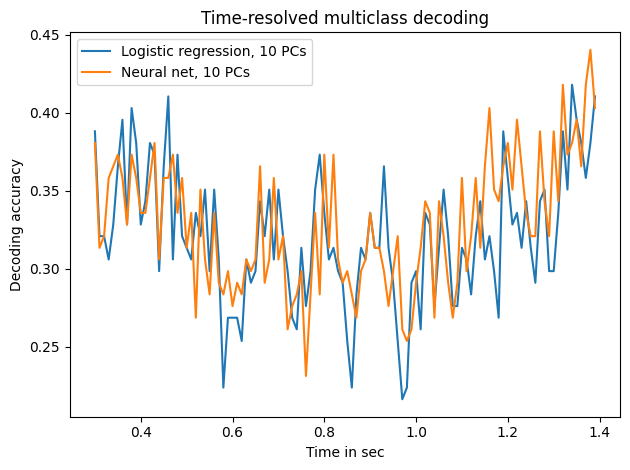

In [15]:
import matplotlib.pyplot as plt
#Accuracy plots:
plt.plot(time_period, logreg_accuracy_list, label="Logistic regression, 10 PCs")

plt.plot(time_period, nn_accuracy_list, label="Neural net, 10 PCs")

plt.xlabel("Time in sec")
plt.ylabel("Decoding accuracy")
plt.title("Time-resolved multiclass decoding")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
#Accuracies for one dataset:
print(f'Accuracy logistic regression: {np.mean(logreg_accuracy_list)}')
print(f'Accuracy neural net: {np.mean(nn_accuracy_list)}')

Accuracy logistic regression: 0.3204884667571234
Accuracy neural net: 0.3281546808101914
